In [2]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("sales.csv")


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# dataset shape
df.shape

(9800, 18)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [8]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['Category'].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [13]:
df['Category'].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

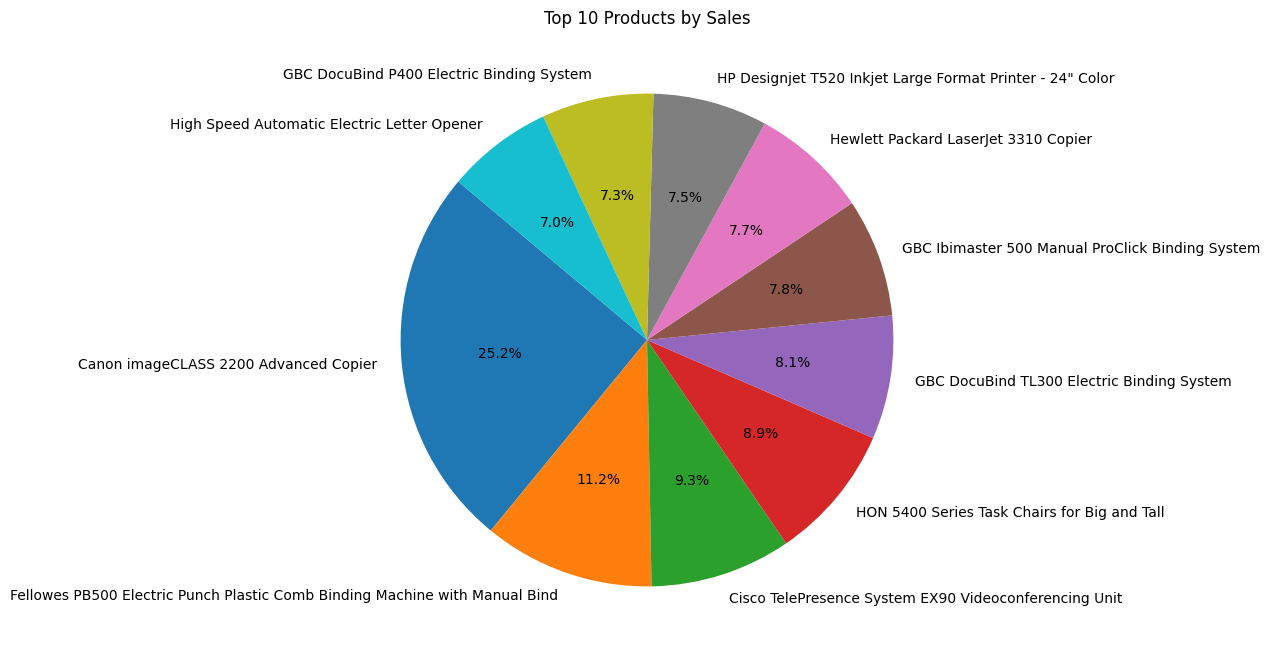

In [38]:
# Top 10 products by sales
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

# Plot Pie Chart
plt.figure(figsize=(8,8))
plt.pie(top_products, 
        labels=top_products.index, 
        autopct='%1.1f%%', 
        startangle=140) 

plt.title("Top 10 Products by Sales")
plt.show()

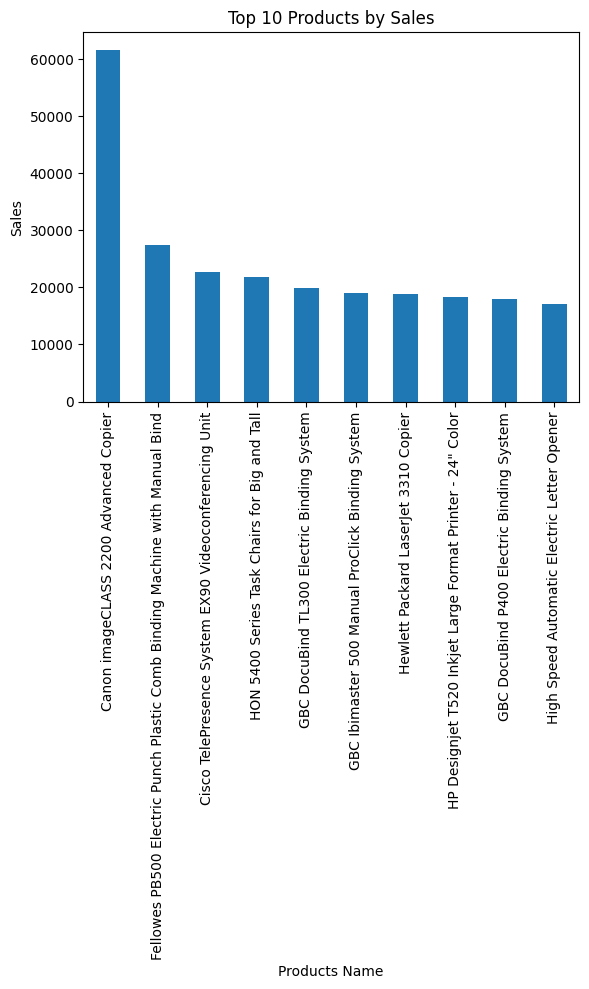

In [15]:
#Graph for visual 
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Products Name")
plt.ylabel("Sales")
plt.show()

In [16]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [22]:
#Convert Datw columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst =True)
df['Ship Date']= pd.to_datetime(df['Ship Date'], dayfirst = True)

In [28]:
df['Shipping_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
print(df['Shipping_Duration'])

0       3
1       3
2       4
3       7
4       7
       ..
9795    7
9796    5
9797    5
9798    5
9799    5
Name: Shipping_Duration, Length: 9800, dtype: int64


In [29]:
sales_by_category = df.groupby('Category')['Sales'].sum()
print(sales_by_category)

sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum()
print(sales_by_subcategory)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64
Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


In [30]:
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)

top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_cities)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64
City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64


In [31]:
print(df['Shipping_Duration'].mean())

3.9611224489795918


In [32]:
delayed = df[df['Shipping_Duration'] > df['Shipping_Duration'].mean()]
print(delayed[['Order ID','Shipping_Duration','Ship Date']])

            Order ID  Shipping_Duration  Ship Date
2     CA-2017-138688                  4 2017-06-16
3     US-2016-108966                  7 2016-10-18
4     US-2016-108966                  7 2016-10-18
5     CA-2015-115812                  5 2015-06-14
6     CA-2015-115812                  5 2015-06-14
...              ...                ...        ...
9795  CA-2017-125920                  7 2017-05-28
9796  CA-2016-128608                  5 2016-01-17
9797  CA-2016-128608                  5 2016-01-17
9798  CA-2016-128608                  5 2016-01-17
9799  CA-2016-128608                  5 2016-01-17

[6650 rows x 3 columns]


In [33]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [34]:
orders_per_customer = df.groupby('Customer Name')['Order ID'].count().sort_values(ascending=False).head(10)
print(orders_per_customer)

Customer Name
William Brown          35
Paul Prost             34
Matt Abelman           34
John Lee               33
Seth Vernon            32
Chloris Kastensmidt    32
Jonathan Doherty       32
Arthur Prichep         31
Emily Phan             31
Zuschuss Carroll       31
Name: Order ID, dtype: int64


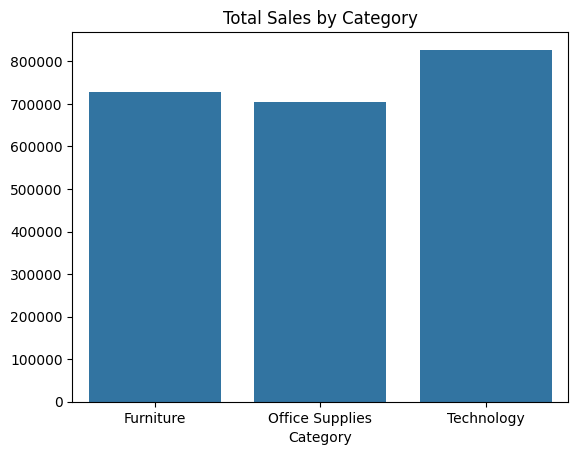

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sales by Category
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)
plt.title("Total Sales by Category")
plt.show()

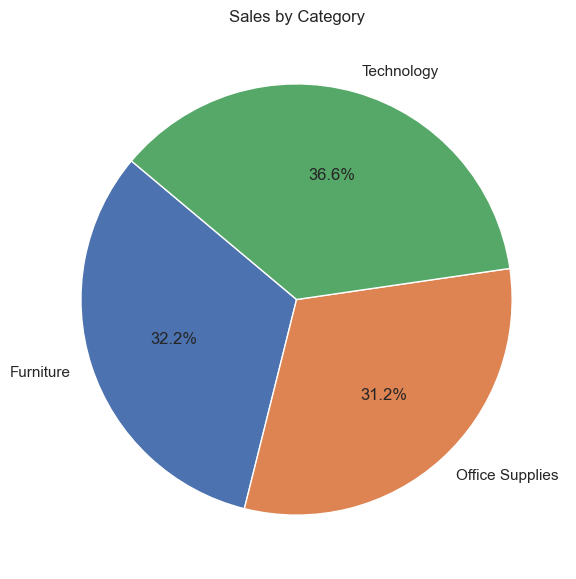

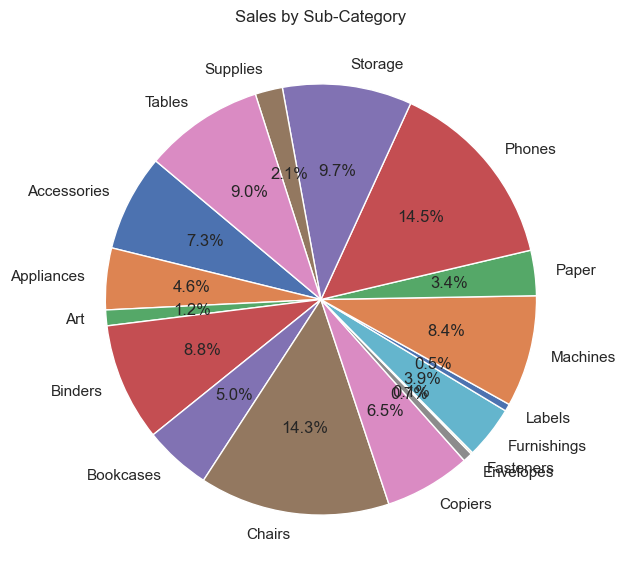

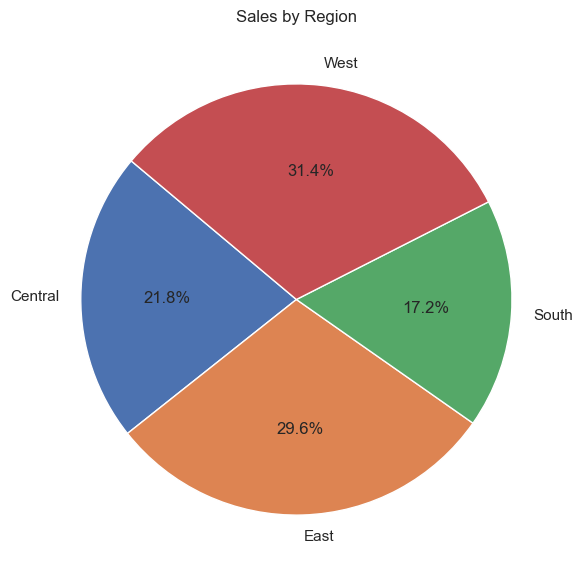

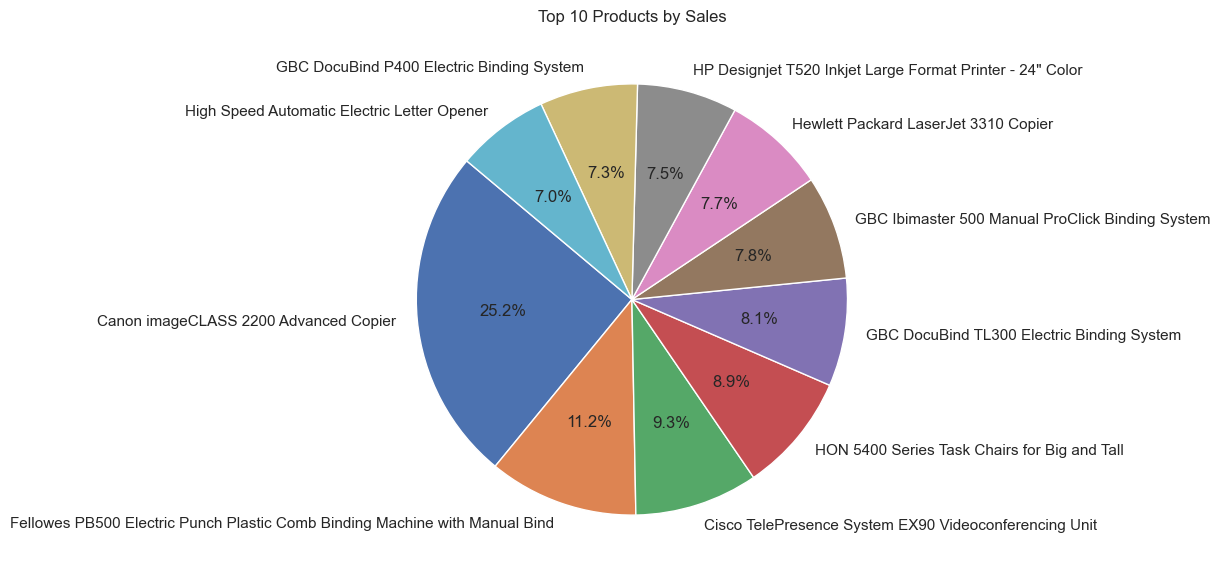

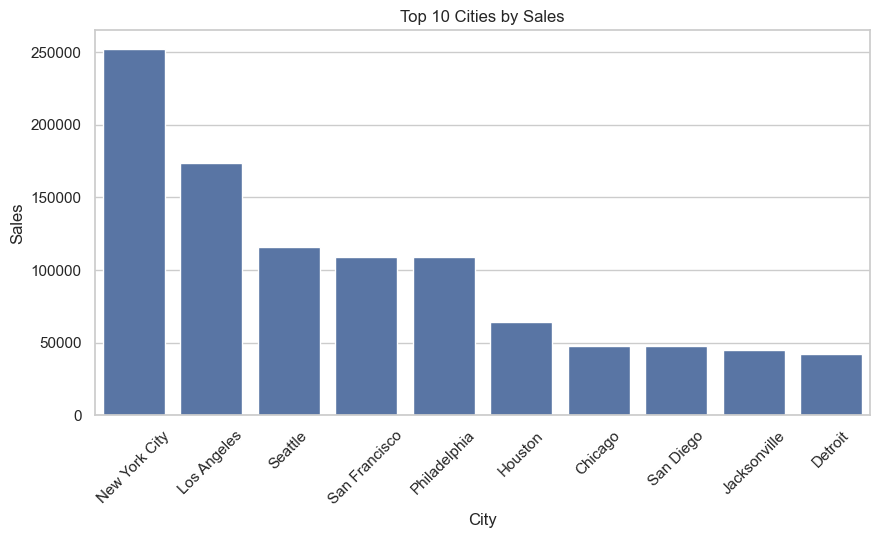

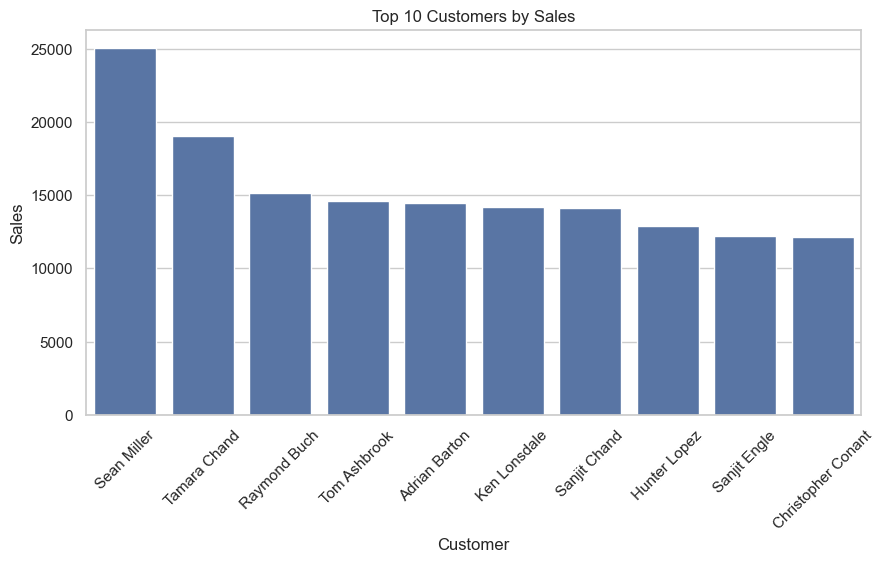

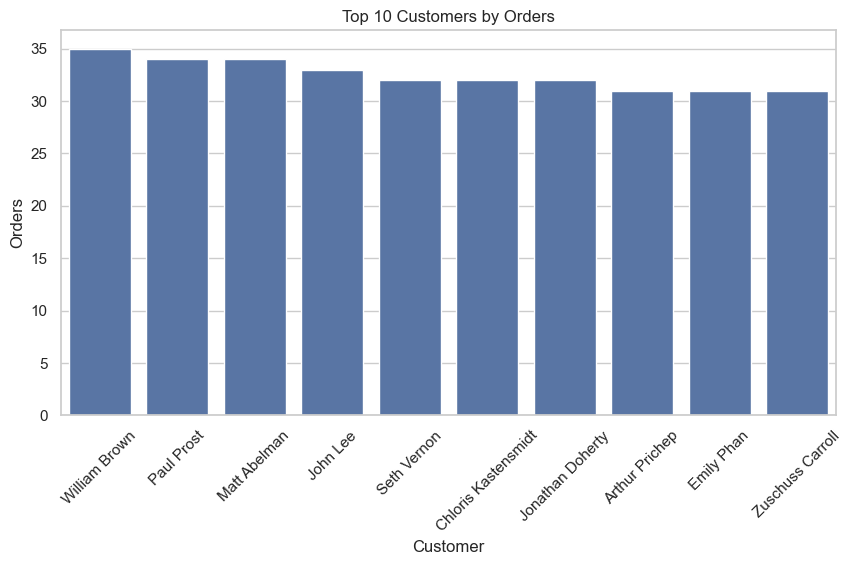

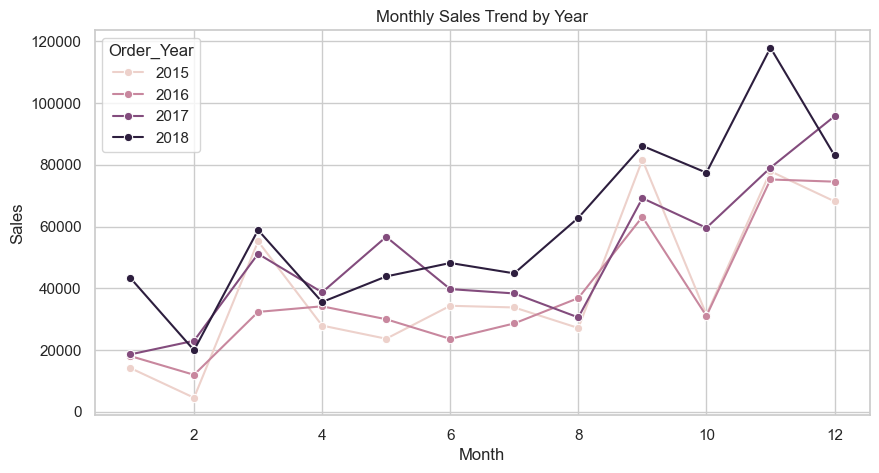

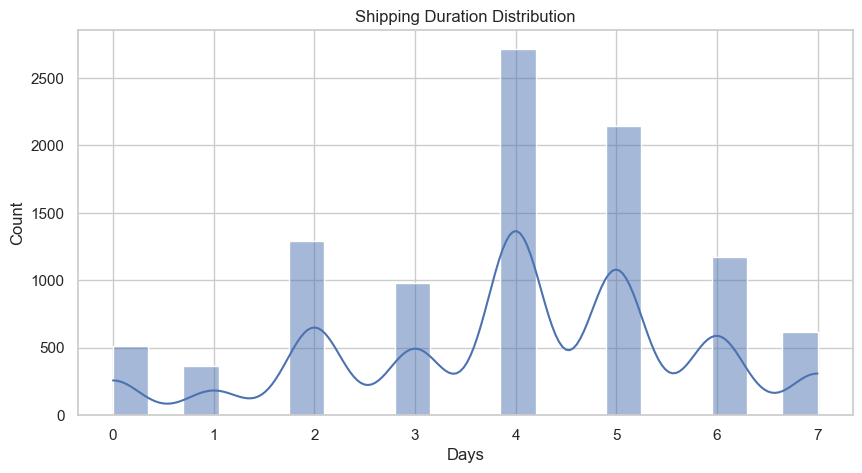

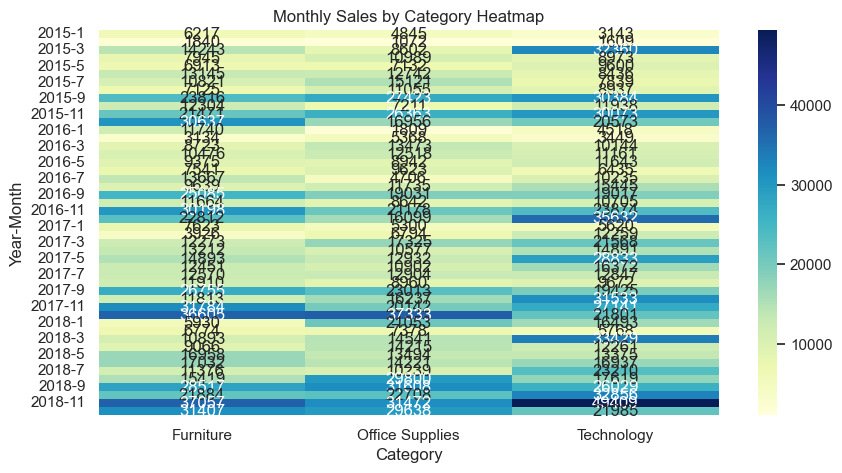

Average Shipping Duration: 3.96 days

Sample Delayed Orders:
          Order ID  Shipping_Duration  Ship Date
2  CA-2017-138688                  4 2017-06-16
3  US-2016-108966                  7 2016-10-18
4  US-2016-108966                  7 2016-10-18
5  CA-2015-115812                  5 2015-06-14
6  CA-2015-115812                  5 2015-06-14

Top Customers by Sales:
 Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

Top Customers by Number of Orders:
 Customer Name
William Brown          35
Paul Prost             34
Matt Abelman           34
John Lee               33
Seth Vernon            32
Chloris Kastensmidt    32
Jonathan Doherty       32
Arthur Prichep         31
Emi

In [39]:
#final Output
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

df['Shipping_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Weekday'] = df['Order Date'].dt.day_name()


category_sales = df.groupby("Category")["Sales"].sum()
sub_category_sales = df.groupby("Sub-Category")["Sales"].sum()
region_sales = df.groupby("Region")["Sales"].sum()
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers_orders = df.groupby("Customer Name")["Order ID"].count().sort_values(ascending=False).head(10)
monthly_sales = df.groupby(['Order_Year','Order_Month'])['Sales'].sum().reset_index()
avg_shipping = df['Shipping_Duration'].mean()
delayed_orders = df[df['Shipping_Duration'] > avg_shipping]

# Pie Charts
def pie_chart(data, title):
    plt.figure(figsize=(7,7))
    plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.show()

pie_chart(category_sales, "Sales by Category")
pie_chart(sub_category_sales, "Sales by Sub-Category")
pie_chart(region_sales, "Sales by Region")
pie_chart(top_products, "Top 10 Products by Sales")


def bar_chart(data, title, xlabel, ylabel):
    sns.barplot(x=data.index, y=data.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

bar_chart(city_sales, "Top 10 Cities by Sales", "City", "Sales")
bar_chart(top_customers_sales, "Top 10 Customers by Sales", "Customer", "Sales")
bar_chart(top_customers_orders, "Top 10 Customers by Orders", "Customer", "Orders")


# Line Chart: Monthly Sales Trend
sns.lineplot(data=monthly_sales, x='Order_Month', y='Sales', hue='Order_Year', marker='o')
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Histogram: Shipping Duration
sns.histplot(df['Shipping_Duration'], bins=20, kde=True)
plt.title("Shipping Duration Distribution")
plt.xlabel("Days")
plt.show()

monthly_category = df.groupby(['Order_Year','Order_Month','Category'])['Sales'].sum().unstack().fillna(0)
sns.heatmap(monthly_category, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Sales by Category Heatmap")
plt.xlabel("Category")
plt.ylabel("Year-Month")
plt.show()


# Print Key Metrics
print(f"Average Shipping Duration: {avg_shipping:.2f} days")
print("\nSample Delayed Orders:\n", delayed_orders[['Order ID','Shipping_Duration','Ship Date']].head())
print("\nTop Customers by Sales:\n", top_customers_sales)
print("\nTop Customers by Number of Orders:\n", top_customers_orders)